# Итоговый разбор гипотезы о завышении рейтингов Fandango

## Исследовательский вопрос
Завышает ли Fandango оценки фильмов по сравнению с другими сайтами и собственной числовой пользовательской оценкой?

## Логика проверки
1. Сначала проверяем, как внутри Fandango соотносятся `STARS` и `RATING`.
2. Затем сравниваем Fandango с Rotten Tomatoes, Metacritic и IMDb на общей шкале `0..5`.
3. Отдельно смотрим на самые слабые фильмы, чтобы проверить, сохраняется ли смещение даже в крайних случаях.


In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='Set2')
ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'analysis' else Path.cwd().resolve()
DATA_DIR = ROOT / 'data'

fandango = pd.read_csv(DATA_DIR / 'fandango_scrape.csv')
all_sites = pd.read_csv(DATA_DIR / 'all_sites_scores.csv')


## Шаг 1. Есть ли смещение внутри самого Fandango?

Если отображаемые звезды (`STARS`) систематически выше числового рейтинга (`RATING`), это уже самостоятельный признак смещения вверх.


In [2]:
fandango_voted = fandango[fandango['VOTES'] > 0].copy()
fandango_voted['STARS_DIFF'] = fandango_voted['STARS'] - fandango_voted['RATING']

fandango_voted[['STARS', 'RATING']].mean().round(3)


STARS     4.123
RATING    3.911
dtype: float64

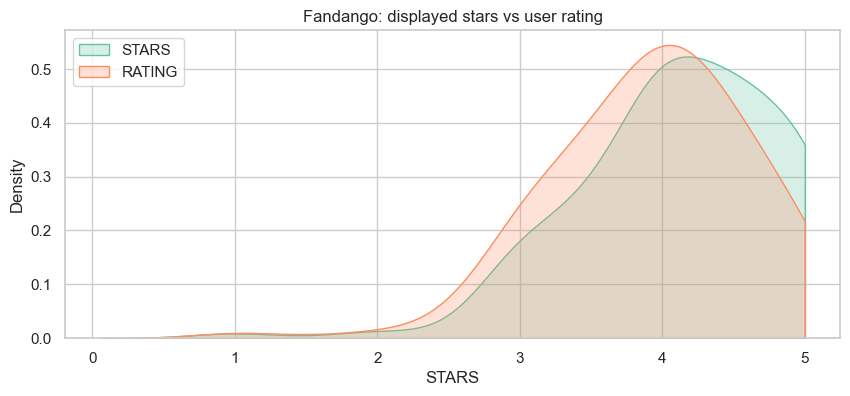

In [3]:
plt.figure(figsize=(10, 4))
sns.kdeplot(fandango_voted['STARS'], label='STARS', clip=(0, 5), fill=True, bw_adjust=1.5)
sns.kdeplot(fandango_voted['RATING'], label='RATING', clip=(0, 5), fill=True, bw_adjust=1.5)
plt.title('Fandango: displayed stars vs user rating')
plt.legend()


Интерпретация: если `STARS` в среднем выше `RATING`, значит сайт показывает более оптимистичную визуальную оценку, чем следует из самих пользовательских значений.


## Шаг 2. Что происходит в сравнении с другими сайтами?

Для честного сравнения нужно привести все рейтинги к единой шкале `0..5`.


In [4]:
merged = pd.merge(fandango, all_sites, on='FILM', how='inner')

norm_scores = pd.DataFrame({
    'film': merged['FILM'],
    'fandango_stars': merged['STARS'],
    'fandango_rating': merged['RATING'],
    'rotten_tomatoes_critics': (merged['RottenTomatoes'] / 20).round(2),
    'rotten_tomatoes_users': (merged['RottenTomatoes_User'] / 20).round(2),
    'metacritic_critics': (merged['Metacritic'] / 20).round(2),
    'metacritic_users': (merged['Metacritic_User'] / 2).round(2),
    'imdb': (merged['IMDB'] / 2).round(2),
})

norm_scores.mean(numeric_only=True).round(2).sort_values(ascending=False)


fandango_stars             4.09
fandango_rating            3.84
imdb                       3.36
metacritic_users           3.25
rotten_tomatoes_users      3.18
rotten_tomatoes_critics    3.03
metacritic_critics         2.93
dtype: float64

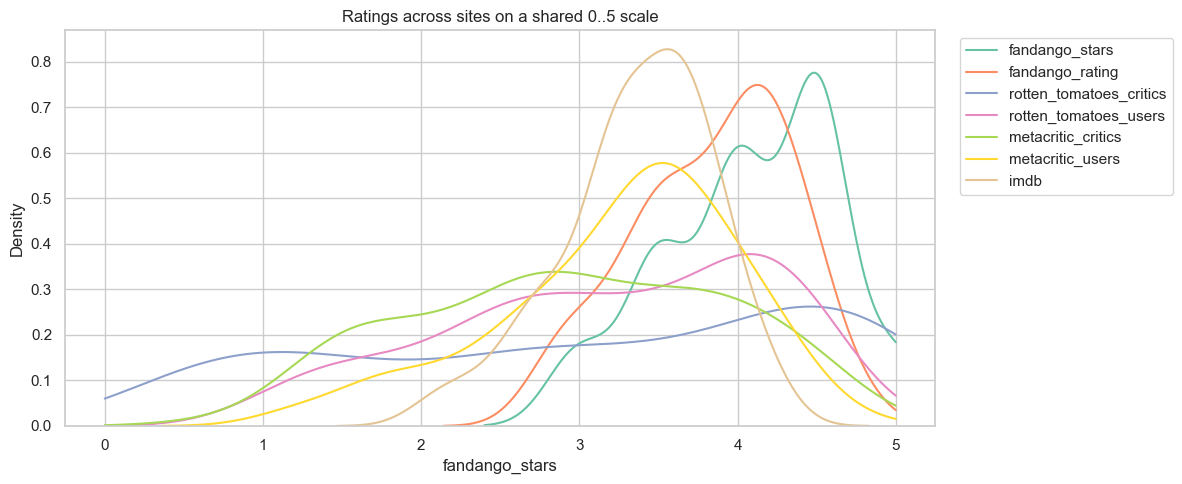

In [5]:
plt.figure(figsize=(12, 5))
for column in [
    'fandango_stars',
    'fandango_rating',
    'rotten_tomatoes_critics',
    'rotten_tomatoes_users',
    'metacritic_critics',
    'metacritic_users',
    'imdb',
]:
    sns.kdeplot(norm_scores[column], label=column, clip=(0, 5), fill=False)

plt.title('Ratings across sites on a shared 0..5 scale')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


Интерпретация: если кривые Fandango расположены правее, чем кривые других сайтов, это означает систематически более высокие оценки.


## Шаг 3. Сохраняется ли эффект на плохих фильмах?

Это важная проверка на устойчивость гипотезы. Если даже у слабых фильмов Fandango остаётся высоким, это сильный аргумент против случайного объяснения.


In [6]:
worst_10 = norm_scores.nsmallest(10, 'rotten_tomatoes_critics')
worst_10.mean(numeric_only=True).round(2).sort_values(ascending=False)


fandango_stars             3.75
fandango_rating            3.47
imdb                       2.62
rotten_tomatoes_users      1.78
metacritic_users           1.76
metacritic_critics         1.34
rotten_tomatoes_critics    0.47
dtype: float64

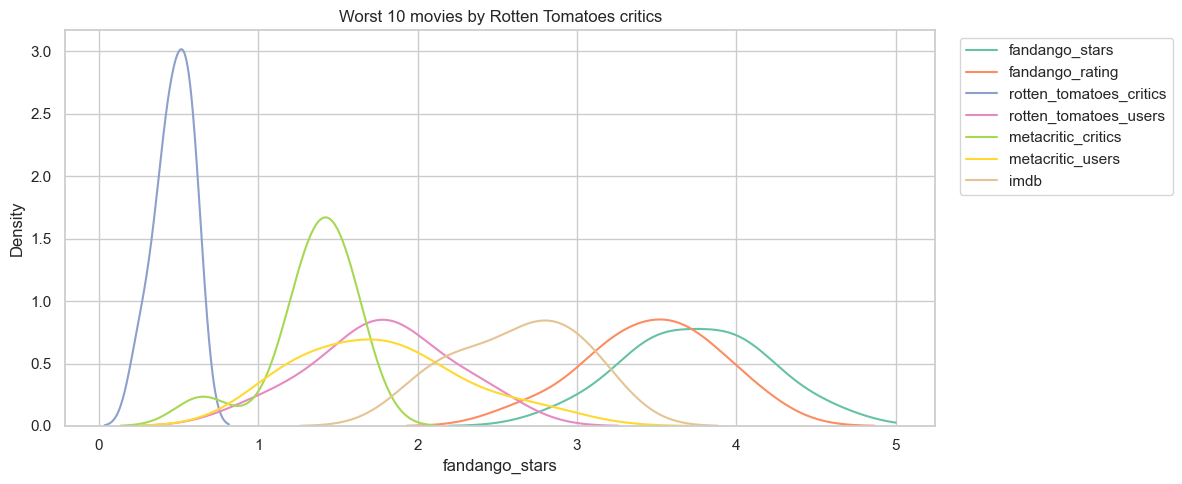

In [7]:
plt.figure(figsize=(12, 5))
for column in [
    'fandango_stars',
    'fandango_rating',
    'rotten_tomatoes_critics',
    'rotten_tomatoes_users',
    'metacritic_critics',
    'metacritic_users',
    'imdb',
]:
    sns.kdeplot(worst_10[column], label=column, clip=(0, 5), fill=False)

plt.title('Worst 10 movies by Rotten Tomatoes critics')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


## Вывод

На этой выборке гипотеза подтверждается:

- внутри Fandango `STARS` выше `RATING`;
- в сравнении с Rotten Tomatoes, Metacritic и IMDb оценки Fandango систематически выше;
- эффект сохраняется даже для фильмов с очень низкими оценками критиков.

Корректный итоговый тезис: **Fandango на этом датасете демонстрирует сильные признаки завышения рейтингов по сравнению с другими сайтами и собственной пользовательской оценкой.**
